# OCTO Mobile Google Play Review - Exploratory Data Analysis (EDA)

**Nama:** Alisha Rafimalia  
**NRP:** 5026231202  
**Kelas:** PBA A  
**Notebook:** 2 - EDA Lanjutan

Notebook ini menyajikan EDA yang lebih lengkap pada data review OCTO Mobile: profil data, kualitas data, analisis distribusi, tren waktu, hubungan antar variabel, serta insight utama untuk rekomendasi perbaikan.

In [1]:
!pip -q install pandas numpy seaborn matplotlib nltk

In [2]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load dataset hasil scraping bersih dari beberapa kemungkinan lokasi
candidate_paths = [
    "../WEEK 2/hasil_scraping_octo_clean.csv",
    "WEEK 2/hasil_scraping_octo_clean.csv",
    "../.qodo/WEEK 2/hasil_scraping_octo_clean.csv",
    "./.qodo/WEEK 2/hasil_scraping_octo_clean.csv",
    ".qodo/WEEK 2/hasil_scraping_octo_clean.csv",
    "hasil_scraping_octo_clean.csv",
]

df = None
used_path = None

for p in candidate_paths:
    try:
        df = pd.read_csv(p)
        used_path = p
        break
    except FileNotFoundError:
        continue

if df is None:
    matches = list(Path.cwd().rglob("hasil_scraping_octo_clean.csv"))
    if matches:
        used_path = str(matches[0])
        df = pd.read_csv(used_path)

if df is None:
    raise FileNotFoundError("File hasil_scraping_octo_clean.csv tidak ditemukan.")

print(f"Data loaded from: {used_path}")
print("Shape:", df.shape)
df.head()

Data loaded from: ../WEEK 2/hasil_scraping_octo_clean.csv
Shape: (5000, 11)


,reviewId,userName,score,content,at,thumbsUpCount,replyContent,repliedAt,review_length,month,sentimen_label
0,b5e135fc-94c4-4a35-bbfc-f8cc3a977367,erli shop,5,faforit banget. user friendly,2026-04-05 13:11:16,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 13:15:19,29,2026-04,positif
1,61ea84b8-43b2-4883-ac0f-d55c99319646,Muhamad Rizki,3,aneh aplikasi sudah versi terbaru tapi tetep G...,2026-04-05 12:54:35,0,Mohon maaf atas ketidaknyamanan yang dialami. ...,2026-04-05 13:15:22,151,2026-04,netral
2,b81ce971-d1d9-4280-958f-39a79847ddb5,tia lestari dewi,5,give good transaction experience,2026-04-05 12:46:55,0,Thank you very much for the compliment! Keep u...,2026-04-05 13:14:55,32,2026-04,positif
3,88a4987c-ef87-4246-a5dc-d5be07fd2eb3,Rony Rihard,5,"CIMB memang virtual account ter ""the best"", cu...",2026-04-05 11:38:12,0,Terima kasih atas supportnya. Aplikasi OCTO se...,2026-04-05 11:45:41,153,2026-04,positif
4,b5298f85-2875-4668-a32d-2f2f4db451b4,Awaluddin M,5,mantap gratis admin,2026-04-05 10:21:01,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 10:45:43,19,2026-04,positif


### Penjelasan Output
- `Data loaded from` menunjukkan sumber file yang berhasil dibaca.
- `Shape` adalah jumlah baris dan kolom dataset.
- Tabel `head()` membantu validasi awal struktur data.

## 1. Data Profiling

Melihat struktur data, tipe data, statistik ringkas, serta contoh data di awal dan akhir.

In [4]:
print("Info dataset:")
display(df.info())

print("\nStatistik numerik:")
display(df.describe(include="number").T)

print("\nStatistik kategorikal/object:")
display(df.describe(include="object").T)

print("\n5 baris awal:")
display(df.head())

print("\n5 baris akhir:")
display(df.tail())

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   reviewId        5000 non-null   str  
 1   userName        5000 non-null   str  
 2   score           5000 non-null   int64
 3   content         5000 non-null   str  
 4   at              5000 non-null   str  
 5   thumbsUpCount   5000 non-null   int64
 6   replyContent    4992 non-null   str  
 7   repliedAt       4992 non-null   str  
 8   review_length   5000 non-null   int64
 9   month           5000 non-null   str  
 10  sentimen_label  5000 non-null   str  
dtypes: int64(3), str(8)
memory usage: 429.8 KB


None


Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
score,5000.0,4.1682,1.519201,1.0,4.0,5.0,5.0,5.0
thumbsUpCount,5000.0,0.3670,3.013126,0.0,0.0,0.0,0.0,118.0
review_length,5000.0,49.1018,66.607747,1.0,10.0,25.0,59.0,500.0



Statistik kategorikal/object:


...

,count,unique,top,freq
reviewId,5000,5000,b5e135fc-94c4-4a35-bbfc-f8cc3a977367,1
userName,5000,4953,Ajat Sudrajat,4
content,5000,3833,mantap,210
at,5000,4999,2026-02-27 13:12:06,2
replyContent,4992,378,Terima kasih atas bintang lima dan review nya....,573
repliedAt,4992,4963,2026-03-25 15:45:22,2
month,5000,10,2026-02,753
sentimen_label,5000,3,positif,3885



5 baris awal:


,reviewId,userName,score,content,at,thumbsUpCount,replyContent,repliedAt,review_length,month,sentimen_label
0,b5e135fc-94c4-4a35-bbfc-f8cc3a977367,erli shop,5,faforit banget. user friendly,2026-04-05 13:11:16,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 13:15:19,29,2026-04,positif
1,61ea84b8-43b2-4883-ac0f-d55c99319646,Muhamad Rizki,3,aneh aplikasi sudah versi terbaru tapi tetep G...,2026-04-05 12:54:35,0,Mohon maaf atas ketidaknyamanan yang dialami. ...,2026-04-05 13:15:22,151,2026-04,netral
2,b81ce971-d1d9-4280-958f-39a79847ddb5,tia lestari dewi,5,give good transaction experience,2026-04-05 12:46:55,0,Thank you very much for the compliment! Keep u...,2026-04-05 13:14:55,32,2026-04,positif
3,88a4987c-ef87-4246-a5dc-d5be07fd2eb3,Rony Rihard,5,"CIMB memang virtual account ter ""the best"", cu...",2026-04-05 11:38:12,0,Terima kasih atas supportnya. Aplikasi OCTO se...,2026-04-05 11:45:41,153,2026-04,positif
4,b5298f85-2875-4668-a32d-2f2f4db451b4,Awaluddin M,5,mantap gratis admin,2026-04-05 10:21:01,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 10:45:43,19,2026-04,positif



5 baris akhir:


,reviewId,userName,score,content,at,thumbsUpCount,replyContent,repliedAt,review_length,month,sentimen_label
4995,cd4c5234-3105-48e0-adc8-6ea5d7eb7fd9,Nuva AF,1,lemot,2025-07-25 11:40:02,0,"Dear Bapak/Ibu, mohon maaf atas ketidaknyamana...",2025-07-25 11:45:50,5,2025-07,negatif
4996,10aa78ff-36a4-4bba-858b-48071f5abad0,dendi Irmansyah,2,Jam segini kgk bisa di akses,2025-07-25 11:39:26,0,"Bapak/Ibu, mohon maaf atas ketidaknyamanan yan...",2025-07-25 11:45:01,28,2025-07,negatif
4997,cf53088d-3196-46e2-ba9f-4fa5a9b81d44,Radit Gacor bana,1,aplikasi nya sering eror gak bisa transaksi da...,2025-07-25 11:27:29,0,Mohon maaf atas ketidaknyamanan yang dialami. ...,2025-07-25 11:44:55,151,2025-07,negatif
4998,54fee458-9265-4673-8fd0-ee4d02fe73be,Raksa Pramadita,1,bintang satu kebagusan untuk aplikasi sampah s...,2025-07-25 11:27:16,0,"Dear Bapak Raksa, mohon maaf atas ketidaknyama...",2025-07-25 11:46:08,59,2025-07,negatif
4999,ccdcc9d3-b44d-4908-90c3-9ba895c35245,Rizky Ingra,3,apalah tiap saat maintenance mulu ga bisa di p...,2025-07-25 11:17:29,0,Mohon maaf atas kendala yang dialami. Untuk in...,2025-07-25 11:45:12,60,2025-07,netral


### Penjelasan Output
- `info()` menampilkan tipe data dan jumlah nilai non-null tiap kolom.
- `describe()` numerik membantu melihat sebaran nilai seperti `score`, `thumbsUpCount`, dan `review_length`.
- `describe()` kategorikal menampilkan jumlah unik dan nilai yang sering muncul.
- `head()` dan `tail()` dipakai untuk sanity check isi data.

## 2. Data Quality Check

Memeriksa missing values, duplikasi, serta validasi kolom penting sebelum analisis.

In [5]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(2)

quality_df = pd.DataFrame({
    "missing_count": missing_summary,
    "missing_pct": missing_pct,
})

dup_count = df.duplicated().sum()
dup_reviewid = df.duplicated(subset=["reviewId"]).sum() if "reviewId" in df.columns else np.nan

print(f"Jumlah baris duplikat penuh: {dup_count}")
print(f"Jumlah duplikat reviewId: {dup_reviewid}")
display(quality_df)

Jumlah baris duplikat penuh: 0
Jumlah duplikat reviewId: 0


,missing_count,missing_pct
replyContent,8,0.16
repliedAt,8,0.16
reviewId,0,0.00
userName,0,0.00
score,0,0.00
content,0,0.00
at,0,0.00
thumbsUpCount,0,0.00
review_length,0,0.00
month,0,0.00


### Penjelasan Output
- Tabel missing values membantu melihat kolom mana yang perlu perhatian saat modeling.
- Duplikasi penuh dan duplikasi `reviewId` menunjukkan apakah data perlu deduplikasi tambahan.

In [6]:
# Persiapan kolom turunan untuk analisis
if "at" in df.columns:
    df["at"] = pd.to_datetime(df["at"], errors="coerce")
if "repliedAt" in df.columns:
    df["repliedAt"] = pd.to_datetime(df["repliedAt"], errors="coerce")

if "sentimen_label" not in df.columns and "score" in df.columns:
    def map_sentimen(score):
        if score >= 4:
            return "positif"
        if score == 3:
            return "netral"
        return "negatif"
    df["sentimen_label"] = df["score"].apply(map_sentimen)

if "review_length" not in df.columns and "content" in df.columns:
    df["review_length"] = df["content"].astype(str).str.len()

if "at" in df.columns:
    df["month"] = df["at"].dt.to_period("M").astype(str)
    df["date"] = df["at"].dt.date

display(df[[c for c in ["score", "sentimen_label", "review_length", "at", "month"] if c in df.columns]].head())

,score,sentimen_label,review_length,at,month
0,5,positif,29,2026-04-05 13:11:16,2026-04
1,3,netral,151,2026-04-05 12:54:35,2026-04
2,5,positif,32,2026-04-05 12:46:55,2026-04
3,5,positif,153,2026-04-05 11:38:12,2026-04
4,5,positif,19,2026-04-05 10:21:01,2026-04


## 3. Univariate Analysis

Melihat distribusi tiap variabel utama secara individual.

/var/folders/jy/25s3m3b54pgdyx0v91ylfww40000gn/T/ipykernel_66658/1391775755.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="score", palette="Blues", ax=axes[0])
/var/folders/jy/25s3m3b54pgdyx0v91ylfww40000gn/T/ipykernel_66658/1391775755.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentimen_label", order=["positif", "netral", "negatif"], palette="Set2", ax=axes[1])


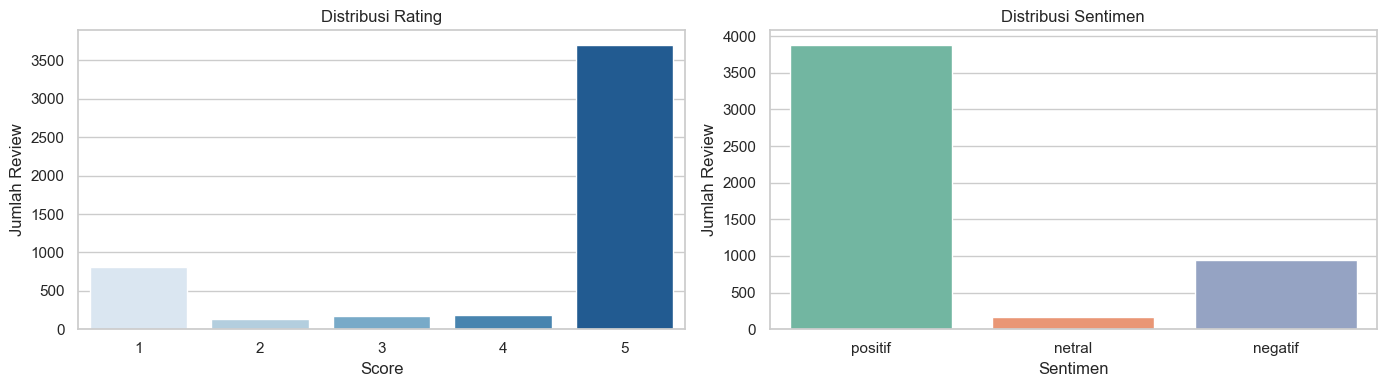

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="score", palette="Blues", ax=axes[0])
axes[0].set_title("Distribusi Rating")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Jumlah Review")

sns.countplot(data=df, x="sentimen_label", order=["positif", "netral", "negatif"], palette="Set2", ax=axes[1])
axes[1].set_title("Distribusi Sentimen")
axes[1].set_xlabel("Sentimen")
axes[1].set_ylabel("Jumlah Review")

plt.tight_layout()
plt.show()

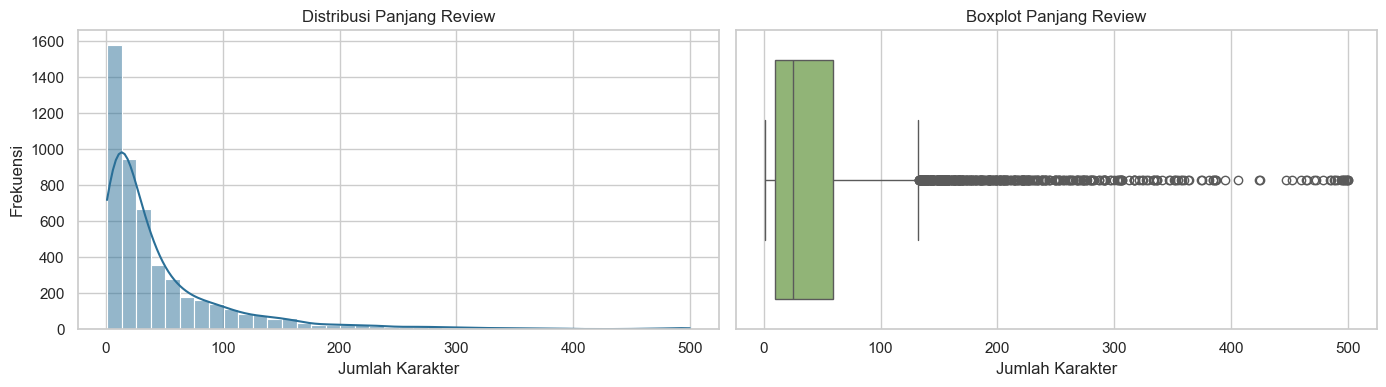

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["review_length"], bins=40, kde=True, color="#2A6F97", ax=axes[0])
axes[0].set_title("Distribusi Panjang Review")
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Frekuensi")

sns.boxplot(data=df, x="review_length", color="#90BE6D", ax=axes[1])
axes[1].set_title("Boxplot Panjang Review")
axes[1].set_xlabel("Jumlah Karakter")

plt.tight_layout()
plt.show()

### Penjelasan Output
- Grafik rating/sentimen menunjukkan komposisi kepuasan user secara umum.
- Histogram dan boxplot `review_length` membantu melihat pola panjang teks dan outlier.
- Distribusi yang sangat miring menandakan perlunya metrik robust (median/IQR) saat pelaporan.

## 4. Temporal Analysis

Menganalisis tren volume review dan perubahan rating dari waktu ke waktu.

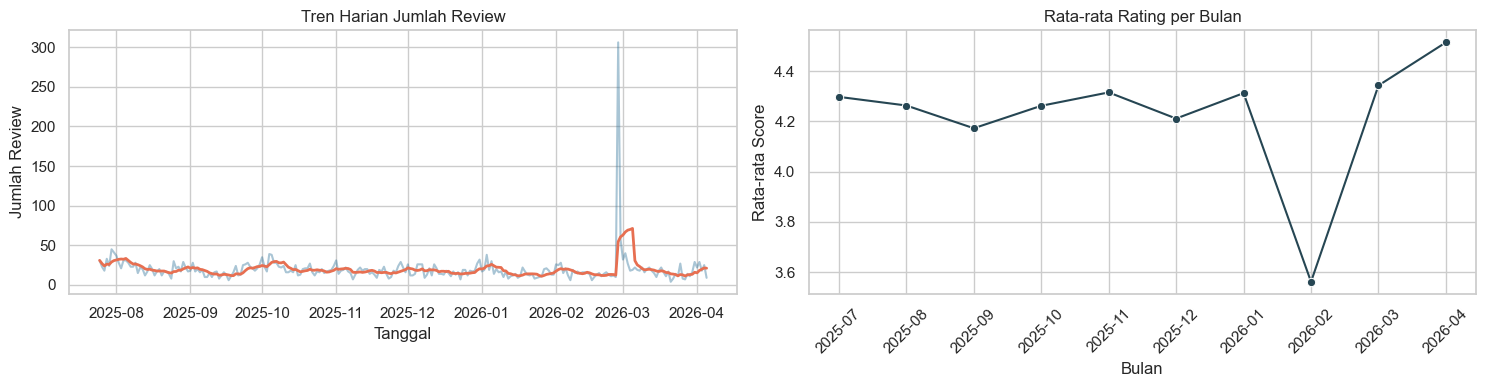

,date,jumlah_review,ma7
250,2026-04-01,22,15.285714
251,2026-04-02,29,18.285714
252,2026-04-03,18,19.857143
253,2026-04-04,25,21.428571
254,2026-04-05,9,21.142857


,month,score
0,2025-07,4.297674
1,2025-08,4.263318
2,2025-09,4.172816
3,2025-10,4.262195
4,2025-11,4.315488
5,2025-12,4.211397
6,2026-01,4.312629
7,2026-02,3.561753
8,2026-03,4.343013
9,2026-04,4.514563


In [9]:
review_daily = df.groupby("date").size().reset_index(name="jumlah_review")
review_daily["date"] = pd.to_datetime(review_daily["date"])
review_daily = review_daily.sort_values("date")
review_daily["ma7"] = review_daily["jumlah_review"].rolling(7, min_periods=1).mean()

rating_monthly = df.groupby("month", as_index=False)["score"].mean()
rating_monthly = rating_monthly.sort_values("month")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.lineplot(data=review_daily, x="date", y="jumlah_review", color="#2A6F97", alpha=0.4, ax=axes[0])
sns.lineplot(data=review_daily, x="date", y="ma7", color="#E76F51", linewidth=2, ax=axes[0])
axes[0].set_title("Tren Harian Jumlah Review")
axes[0].set_xlabel("Tanggal")
axes[0].set_ylabel("Jumlah Review")

sns.lineplot(data=rating_monthly, x="month", y="score", marker="o", color="#264653", ax=axes[1])
axes[1].set_title("Rata-rata Rating per Bulan")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("Rata-rata Score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(review_daily.tail())
display(rating_monthly)

### Penjelasan Output
- Garis tren harian + MA7 membantu membedakan noise harian dari tren utama.
- Grafik rating bulanan menunjukkan apakah kualitas pengalaman pengguna membaik atau menurun.
- Tabel di bawah grafik membantu validasi angka secara eksplisit.

## 5. Bivariate Analysis

Melihat hubungan antara rating, panjang review, dan engagement (`thumbsUpCount`).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x="score", y="review_length", palette="crest", ax=axes[0])
axes[0].set_title("Panjang Review berdasarkan Rating")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Review Length")
axes[0].set_ylim(0, df["review_length"].quantile(0.95))

sns.scatterplot(
    data=df.sample(min(1500, len(df)), random_state=42),
    x="review_length",
    y="thumbsUpCount",
    hue="score",
    palette="viridis",
    alpha=0.5,
    ax=axes[1]
    )
axes[1].set_title("Review Length vs ThumbsUpCount")
axes[1].set_xlabel("Review Length")
axes[1].set_ylabel("Thumbs Up Count")

plt.tight_layout()
plt.show()

In [ ]:
# Analisis respons developer
if "replyContent" in df.columns:
    df["is_replied"] = df["replyContent"].notna() & (df["replyContent"].astype(str).str.strip() != "")
else:
    df["is_replied"] = False

if "at" in df.columns and "repliedAt" in df.columns:
    df["response_hours"] = (df["repliedAt"] - df["at"]).dt.total_seconds() / 3600
else:
    df["response_hours"] = np.nan

reply_rate = df["is_replied"].mean() * 100
median_response = df.loc[df["response_hours"] > 0, "response_hours"].median()

print(f"Reply rate: {reply_rate:.2f}%")
print(f"Median response time (jam): {median_response:.2f}")

reply_by_score = df.groupby("score", as_index=False)["is_replied"].mean()
reply_by_score["is_replied"] = (reply_by_score["is_replied"] * 100).round(2)
display(reply_by_score)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=reply_by_score, x="score", y="is_replied", color="#2A9D8F", ax=axes[0])
axes[0].set_title("Reply Rate per Rating")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Reply Rate (%)")

resp = df.loc[df["response_hours"].between(0, df["response_hours"].quantile(0.95)), "response_hours"]
sns.histplot(resp, bins=30, kde=True, color="#E76F51", ax=axes[1])
axes[1].set_title("Distribusi Waktu Respons (jam)")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

### Penjelasan Output
- Bivariate plot menunjukkan hubungan rating, panjang review, dan engagement.
- Metrik `reply rate` menggambarkan tingkat respons tim terhadap ulasan pengguna.
- Distribusi `response_hours` membantu menilai kecepatan pelayanan setelah user memberi review.

## 6. Text Insight: Top Keywords

Mengidentifikasi kata paling dominan secara umum dan khusus pada review negatif.

In [ ]:
stop_id = set(stopwords.words("indonesian"))
stop_en = set(stopwords.words("english"))
stop_custom = {"yang", "dan", "untuk", "dengan", "nya", "aja", "octo", "cimb", "niaga"}
stop_all = stop_id.union(stop_en).union(stop_custom)

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    toks = [t for t in text.split() if len(t) > 2 and t not in stop_all]
    return toks

all_tokens = []
for tx in df["content"].fillna("").tolist():
    all_tokens.extend(simple_tokenize(tx))

neg_tokens = []
for tx in df.loc[df["sentimen_label"] == "negatif", "content"].fillna("").tolist():
    neg_tokens.extend(simple_tokenize(tx))

top_all = pd.DataFrame(Counter(all_tokens).most_common(20), columns=["word", "freq"])
top_neg = pd.DataFrame(Counter(neg_tokens).most_common(20), columns=["word", "freq"])

display(top_all.head(10))
display(top_neg.head(10))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top_all.head(10), x="freq", y="word", palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 10 Keywords - Semua Review")
axes[0].set_xlabel("Frekuensi")
axes[0].set_ylabel("Kata")

sns.barplot(data=top_neg.head(10), x="freq", y="word", palette="Reds_r", ax=axes[1])
axes[1].set_title("Top 10 Keywords - Review Negatif")
axes[1].set_xlabel("Frekuensi")
axes[1].set_ylabel("Kata")

plt.tight_layout()
plt.show()

### Penjelasan Output
- Tabel/grafik kiri menggambarkan tema umum yang paling sering disebut pengguna.
- Tabel/grafik kanan fokus pada keluhan dominan dari review negatif.
- Kata di sisi negatif dapat dijadikan prioritas perbaikan layanan/aplikasi.

## 7. Key Insights dan Rekomendasi

1. Mayoritas review cenderung positif, namun review negatif menyimpan isu spesifik yang berulang.
2. Monitoring tren harian dan rata-rata rating bulanan penting untuk early warning.
3. Metrik respons developer (reply rate dan response time) dapat dipakai sebagai KPI service quality.
4. Kata dominan pada sentimen negatif sebaiknya dijadikan prioritas backlog perbaikan produk.

### Next Step (Opsional)
- Lanjutkan ke modeling sentimen (Naive Bayes / Logistic Regression / SVM) menggunakan fitur BoW/TF-IDF.
- Buat dashboard periodik untuk tracking rating, volume keluhan, dan SLA respons.